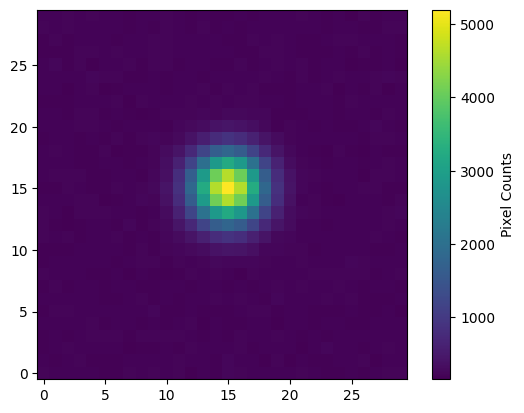

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_toy_star():
    image = np.random.normal(loc=200, scale=15, size=(30, 30))
    y, x = np.mgrid[0:30, 0:30]
    distance_sq = (x - 15)**2 + (y - 15)**2
    star_flux = 5000 * np.exp(-distance_sq / 8) 
    
    image += star_flux
    return image, 15, 15 

image, x_c, y_c = generate_toy_star()

plt.imshow(image, cmap='viridis', origin='lower')
plt.colorbar(label='Pixel Counts')
plt.show()

In [7]:
#Calculating Maxima

m = np.max(image)

# Setting a range of values for FWHM
tolerance = 0.1 * (m / 2)

#Extracting pixel indices at HM and calculating their distances
coords = np.argwhere(np.abs(image - m/2) <= tolerance)

distances = []

for a,b in coords:
    dist_sq = (a-15)**2 + (b-15)**2
    distances.append(np.sqrt(dist_sq))

fwhm = np.mean(distances)

#Taking aperture to be 1.25 times FWHM
ap = 1.25*fwhm

print(fwhm)
print (f'Aperture = {ap}')

2.23606797749979
Aperture = 2.7950849718747373


In [9]:
clean_image, _, _ = generate_toy_star()

#Define your exact values
fwhm = 2.23606797749979
ap = 1.25 * fwhm

#Setting annulus
ann_in = 4*fwhm
ann_out = 6*fwhm

#Calculate the distance of every pixel from the center
c,d = np.mgrid[0:30, 0:30]
distances = np.sqrt((c - 15)**2 + (d - 15)**2)

#Creating annulus and calculating background noise
ann = (distances>=ann_in) & (distances<=ann_out)
ann_flux_values = clean_image[ann]

bkg = np.median(ann_flux_values)

#Calculating flux of star from aperture
aperture = (distances<=ap)
ap_flux_values = clean_image[aperture]
flux = np.sum(ap_flux_values)

#Subtracting background noise from star to obtain m_inst
signal = flux - (bkg*len(ap_flux_values))
m_inst = -2.5 * np.log10(signal)

print (flux)
print (bkg)
print (signal)
print (m_inst)



75990.337266112
199.72889588605207
71796.0304525049
